## import module

In [49]:
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 34 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/

In [52]:
!apt-get -qq install fonts-nanum
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

import optuna
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.ensemble import RandomForestRegressor, StackingRegressor, VotingRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import Ridge




# **📊 EDA 분석 결과 요약**

In [34]:

# 한글 깨짐 방지 (로컬 한글 폰트 경로 설정이 필요할 수 있음)
plt.rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False

# 데이터 로딩
train = pd.read_csv("train.csv")
test = pd.read_csv('test.csv')
submission = pd.read_csv('sample_submission.csv')


plt.rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False

1. 기본정보

In [15]:
print("기본 정보")
print(train.info())

print("\n앞부분 미리 보기")
print(train.head())

기본 정보
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4376 entries, 0 to 4375
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   ID              4376 non-null   object 
 1   설립연도            4376 non-null   int64  
 2   국가              4376 non-null   object 
 3   분야              3519 non-null   object 
 4   투자단계            4376 non-null   object 
 5   직원 수            4202 non-null   float64
 6   인수여부            4376 non-null   object 
 7   상장여부            4376 non-null   object 
 8   고객수(백만명)        3056 non-null   float64
 9   총 투자금(억원)       4376 non-null   float64
 10  연매출(억원)         4376 non-null   float64
 11  SNS 팔로워 수(백만명)  4376 non-null   float64
 12  기업가치(백억원)       3156 non-null   object 
 13  성공확률            4376 non-null   float64
dtypes: float64(6), int64(1), object(7)
memory usage: 478.8+ KB
None

앞부분 미리 보기
           ID  설립연도     국가    분야      투자단계    직원 수 인수여부 상장여부  고객수(백만명)  \
0  TRAIN_0000

2. 결측치 확인

In [16]:
print("\n결측치 개수")
print(train.isnull().sum().sort_values(ascending=False))


결측치 개수
고객수(백만명)          1320
기업가치(백억원)         1220
분야                 857
직원 수               174
설립연도                 0
ID                   0
투자단계                 0
국가                   0
상장여부                 0
인수여부                 0
총 투자금(억원)            0
연매출(억원)              0
SNS 팔로워 수(백만명)       0
성공확률                 0
dtype: int64


3. 기술통계

In [17]:
print("\n수치형 기술통계")
print(train.describe())
print("\n범주형 기술통계")
print(train.describe(include='object'))


수치형 기술통계
              설립연도         직원 수     고객수(백만명)    총 투자금(억원)       연매출(억원)  \
count  4376.000000  4202.000000  3056.000000  4376.000000   4376.000000   
mean   2012.006856  2471.324369    49.214332  3314.568556   6452.202239   
std       6.554872  1446.064215    27.141242  1880.103831   3782.792656   
min    2001.000000     5.000000     1.000000    12.000000     12.000000   
25%    2006.000000  1218.250000    27.000000  1651.500000   3094.250000   
50%    2012.000000  2472.000000    49.000000  3398.000000   6478.500000   
75%    2018.000000  3727.500000    72.000000  4908.250000   9692.500000   
max    2023.000000  4998.000000    99.000000  7059.000000  14822.000000   

       SNS 팔로워 수(백만명)         성공확률  
count     4376.000000  4376.000000  
mean         2.578103     0.537340  
std          1.414590     0.241698  
min          0.000000     0.100000  
25%          1.320000     0.400000  
50%          2.835000     0.600000  
75%          4.000000     0.700000  
max          5.000

4. 범주형 변수 분포

In [18]:
cat_cols = ['국가', '분야', '투자단계', '인수여부', '상장여부', '기업가치(백억원)']
for col in cat_cols:
    print(f"\n{col} 값 분포:")
    print(train[col].value_counts(dropna=False))


국가 값 분포:
국가
CT001    476
CT003    454
CT010    453
CT005    446
CT008    444
CT002    436
CT004    427
CT007    424
CT009    410
CT006    406
Name: count, dtype: int64

분야 값 분포:
분야
NaN     857
에너지     396
기술      389
에듀테크    364
게임      359
AI      356
핀테크     344
푸드테크    335
이커머스    332
물류      328
헬스케어    316
Name: count, dtype: int64

투자단계 값 분포:
투자단계
IPO         938
Series A    876
Seed        875
Series B    849
Series C    838
Name: count, dtype: int64

인수여부 값 분포:
인수여부
Yes    2257
No     2119
Name: count, dtype: int64

상장여부 값 분포:
상장여부
No     2263
Yes    2113
Name: count, dtype: int64

기업가치(백억원) 값 분포:
기업가치(백억원)
NaN          1220
4500-6000     679
2500-3500     635
3500-4500     628
1500-2500     621
6000이상        593
Name: count, dtype: int64


5. 결측 히트맵

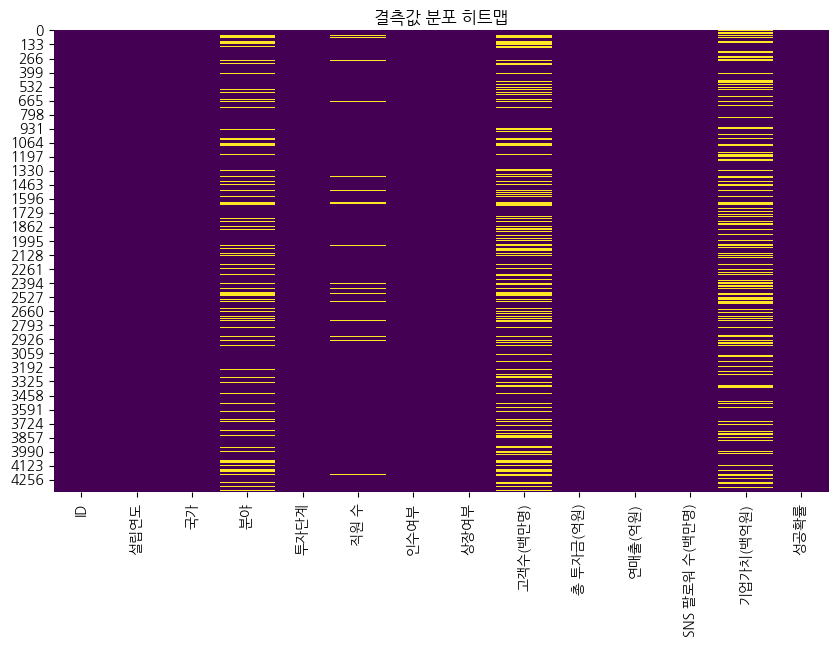

In [19]:
plt.figure(figsize=(10,6))
sns.heatmap(train.isnull(), cbar=False, cmap="viridis")
plt.title("결측값 분포 히트맵")
plt.show()

6. 수치형 변수 히스토그램

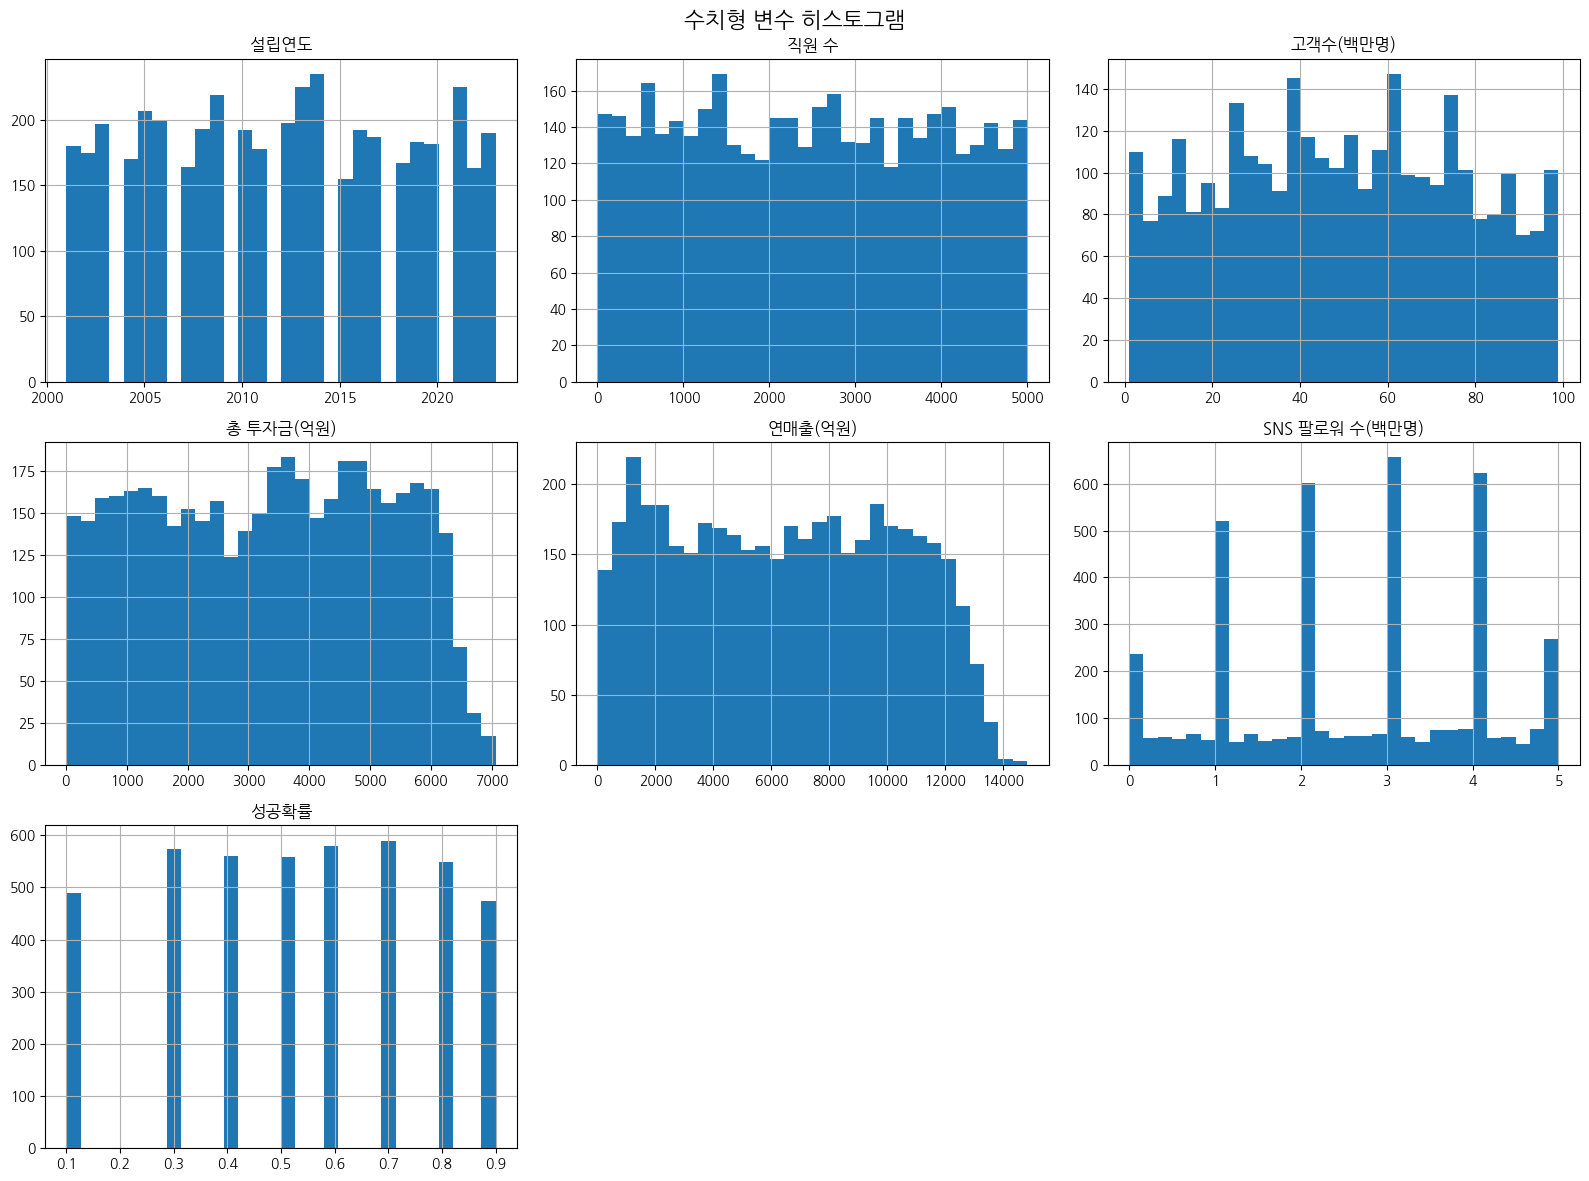

In [20]:
num_cols = train.select_dtypes(include=['float64', 'int64']).columns
train[num_cols].hist(bins=30, figsize=(16, 12))
plt.suptitle("수치형 변수 히스토그램", fontsize=16)
plt.tight_layout()
plt.show()

7. 박스플롯으로 이상치 시각화

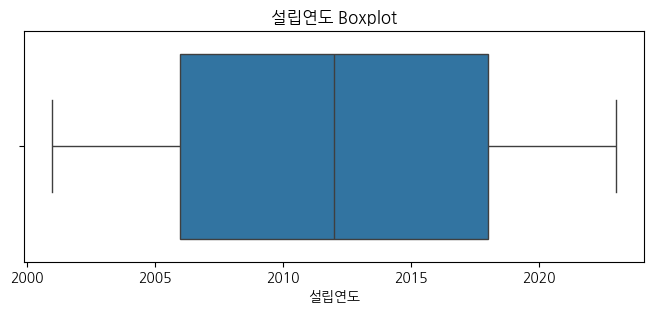

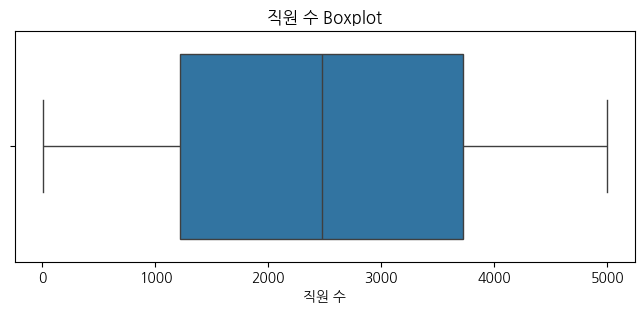

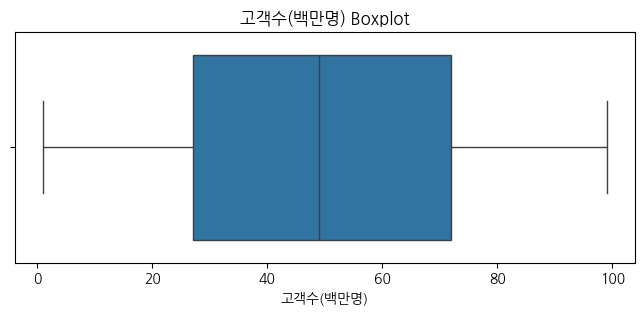

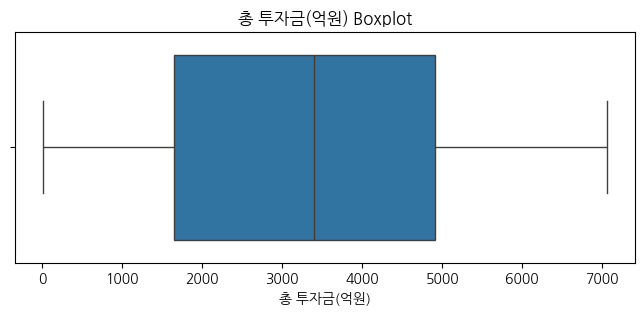

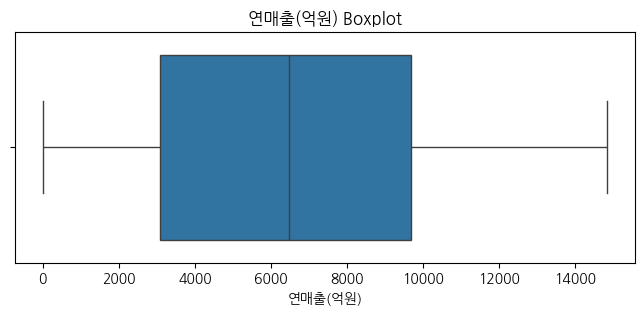

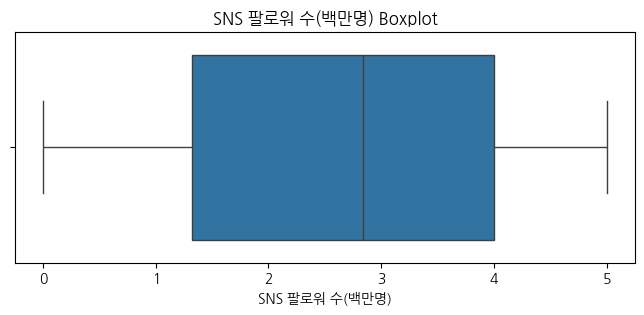

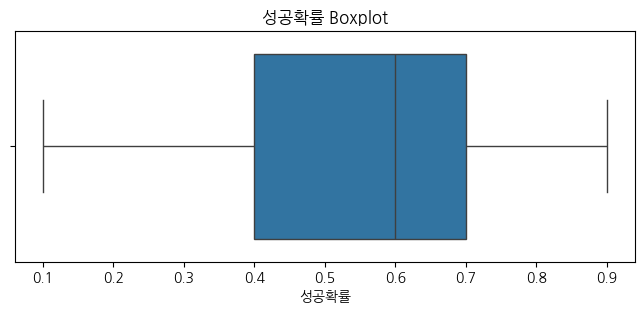

In [21]:
for col in num_cols:
    plt.figure(figsize=(8, 3))
    sns.boxplot(x=train[col])
    plt.title(f"{col} Boxplot")
    plt.show()

8. 상관관계 히트맵

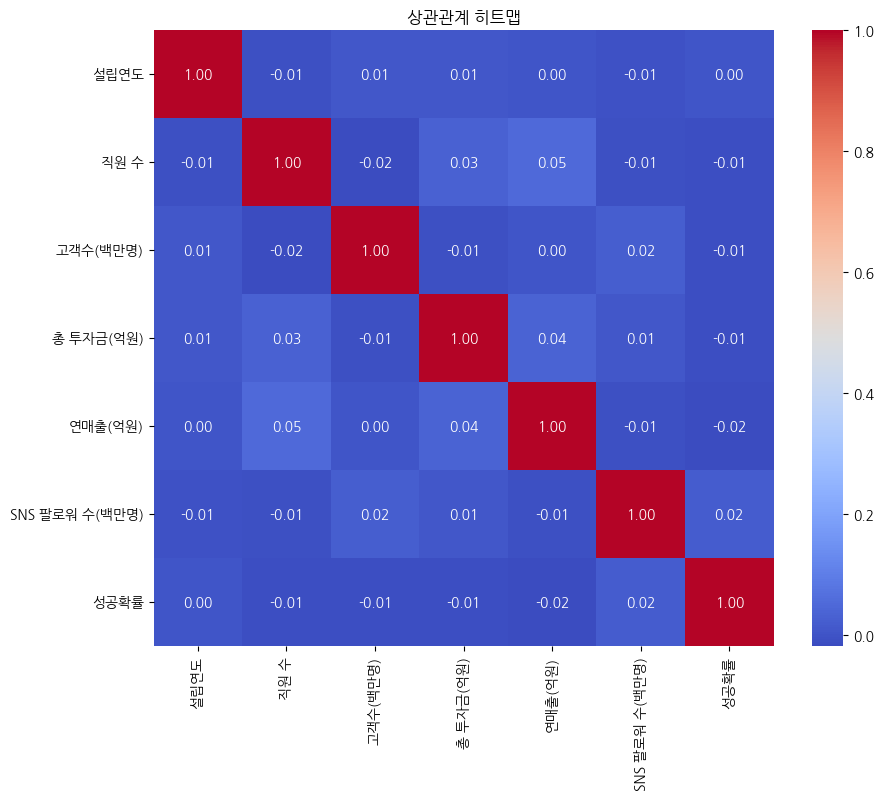

In [22]:
plt.figure(figsize=(10, 8))
corr = train.corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("상관관계 히트맵")
plt.show()

9. 타겟 변수(성공확률)과 범주형 변수 간 분포

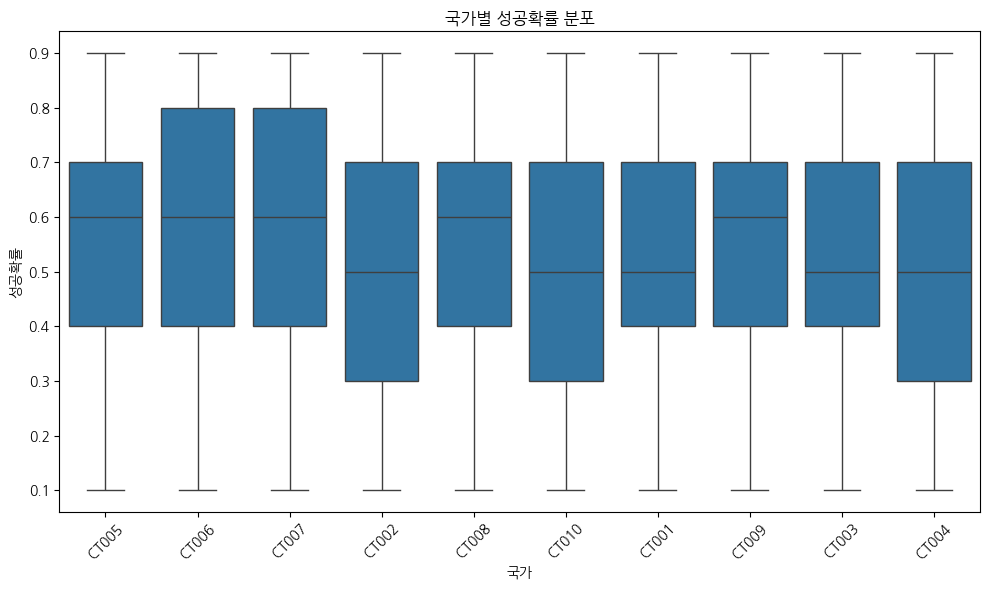

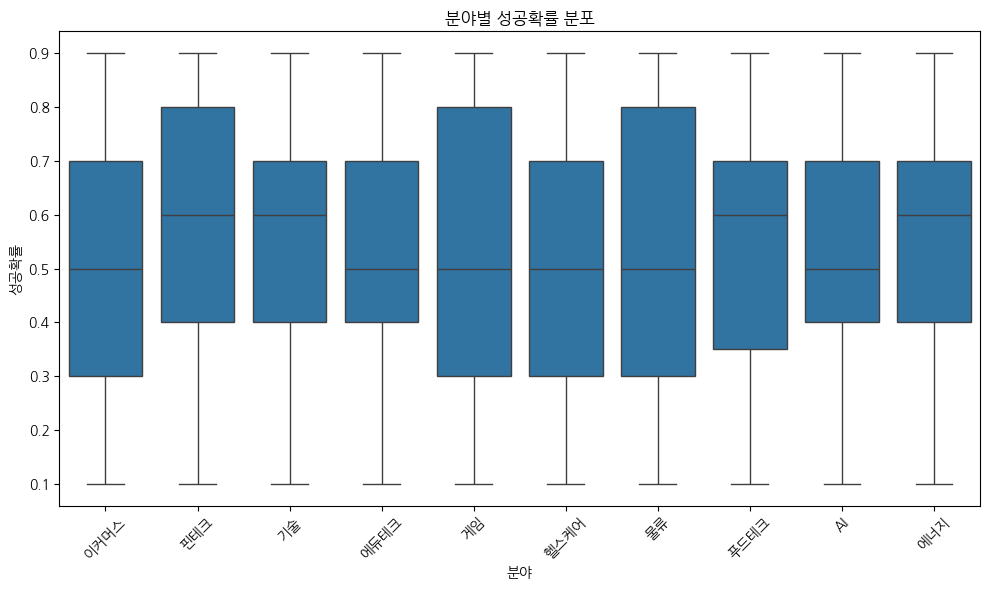

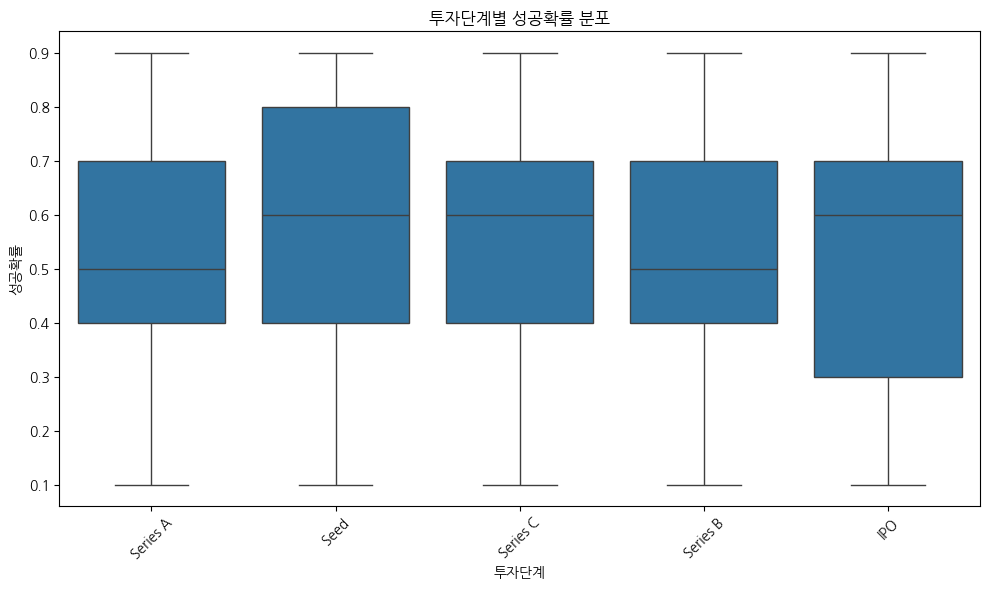

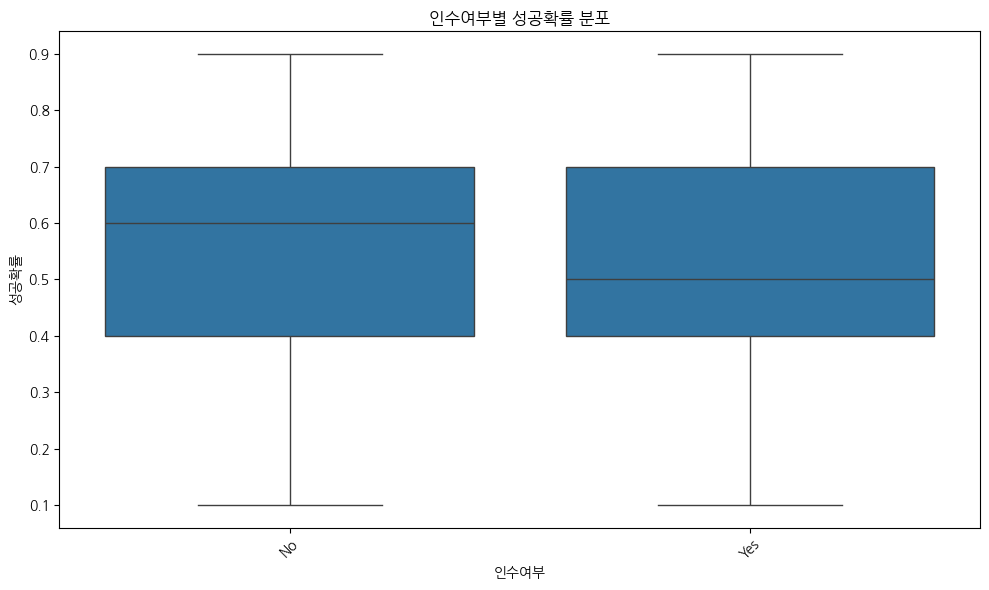

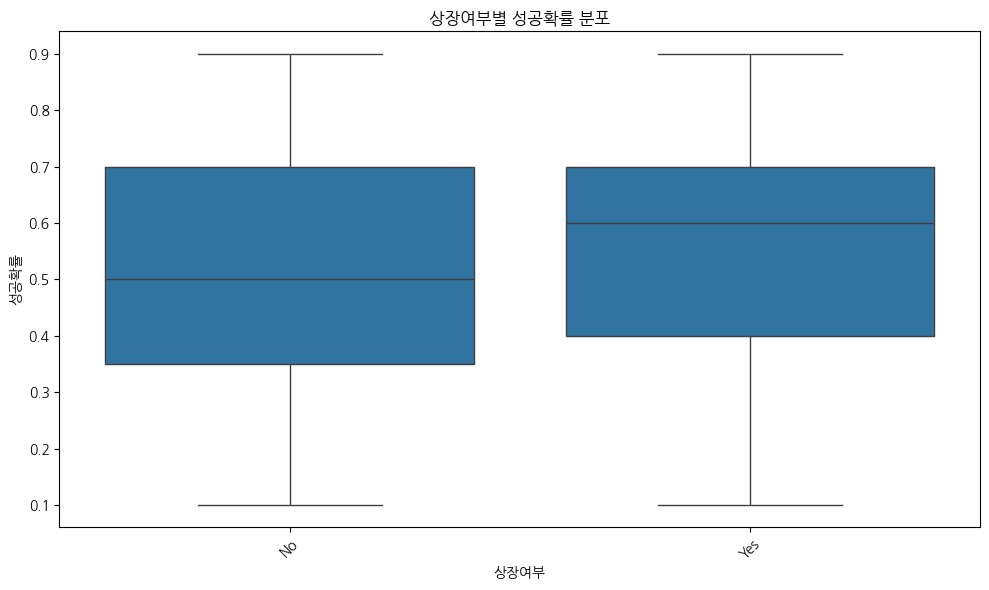

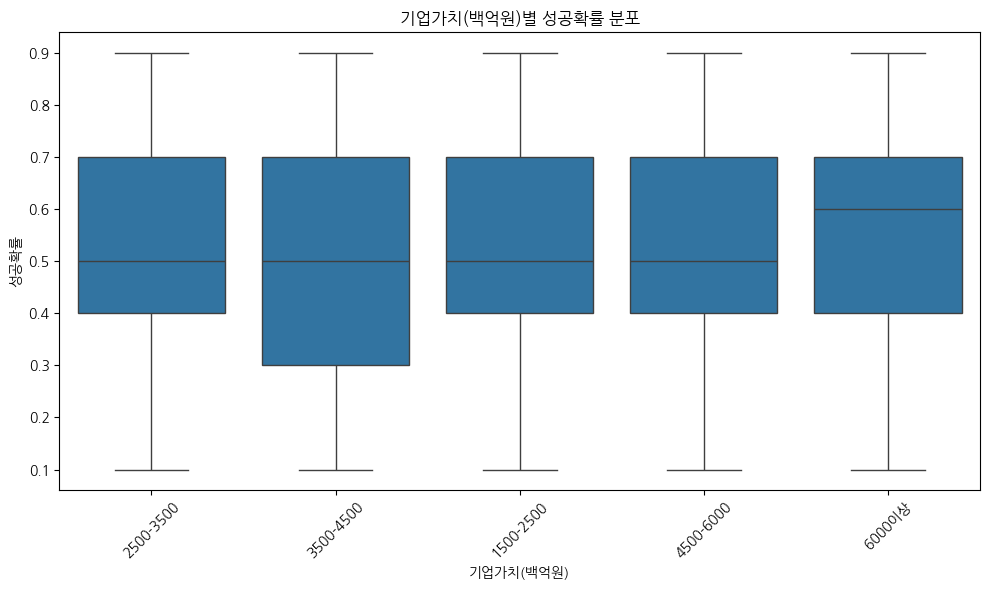

In [23]:
for col in cat_cols:
    plt.figure(figsize=(10, 6))
    sns.boxplot(x=col, y='성공확률', data=train)
    plt.title(f'{col}별 성공확률 분포')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


# **📦 전처리 요약 결과**

1. 기업가치 수치화 함수 정의

In [31]:
def convert_valuation(value):
    if isinstance(value, str):
        if '-' in value:
            low, high = map(int, value.split('-'))
            return (low + high) / 2
        elif '이상' in value:
            return 6000
        elif '미만' in value:
            return 1000
    return np.nan

2. 공통 전처리 함수 정의

In [32]:
def preprocess(df, ref_df=None):
    df = df.copy()

    df['고객수(백만명)'] = df['고객수(백만명)'].fillna(train['고객수(백만명)'].median())
    df['직원 수'] = df['직원 수'].fillna(train['직원 수'].median())
    df['분야'] = df['분야'].fillna('기타')
    df['기업가치(백억원)'] = df['기업가치(백억원)'].fillna('Unknown')

    df['기업가치_num'] = df['기업가치(백억원)'].apply(convert_valuation)
    df['기업가치_num'] = df['기업가치_num'].fillna(train['기업가치(백억원)'].apply(convert_valuation).median())

    for col in ['총 투자금(억원)', '연매출(억원)', 'SNS 팔로워 수(백만명)', '직원 수']:
        df[col] = np.log1p(df[col])

    return df

3. 전처리 적용

In [35]:
train = preprocess(train)
test = preprocess(test)

4. 범주형 인코딩

In [36]:
categorical_cols = ['국가', '분야', '투자단계', '인수여부', '상장여부', '기업가치(백억원)']
combined = pd.concat([train[categorical_cols], test[categorical_cols]], axis=0)

for col in categorical_cols:
    le = LabelEncoder()
    le.fit(combined[col].astype(str))
    train[col] = le.transform(train[col].astype(str))
    test[col] = le.transform(test[col].astype(str))

# **Colab용 모델링 전체 코드 (RandomForest + 평가 + 시각화)**

In [37]:
pip install optuna==4.3.0

1. 입력과 타겟 분리

In [39]:
X = train.drop(columns=['ID', '성공확률'])
y = train['성공확률']
X_test = test.drop(columns=['ID'])

2. 기본 모델 정의(Rf, XGB, lgbm)

In [47]:
base_models = [
    ('rf', RandomForestRegressor(n_estimators=300, max_depth=12, random_state=42)),
    ('xgb', XGBRegressor(n_estimators=300, learning_rate=0.1, max_depth=6, random_state=42)),
    ('lgbm', LGBMRegressor(n_estimators=300, learning_rate=0.1, max_depth=6, random_state=42))
]

3. 스태킹 모델 정의

In [53]:
stacking_model = StackingRegressor(
    estimators=base_models,
    final_estimator=Ridge(alpha=1.0),
    cv=5,
    n_jobs=-1
)

4. 결과 저장

In [54]:
voting_model = VotingRegressor(estimators=[
    ('rf', rf_model),
    ('xgb', xgb_model)
], weights=[7, 3])
voting_model.fit(X, y)

📊 Stacking MAE on validation set: 0.2034
✅ 'stacking_submission.csv' 저장 완료


5. 예측 및 저장